# Generate distribution plots of the features used in the contamination detector

In [1]:
from pathlib import Path

import pandas as pd
from cytodataframe import CytoDataFrame
from plotnine import (
    aes,
    element_text,
    facet_wrap,
    geom_bar,
    ggplot,
    labs,
    scale_fill_gradientn,
    theme,
    theme_bw,
    ylim,
)
from plotnine.options import set_option

from cosmicqc import find_outliers

In [2]:
# Directory with data
data_dir = Path(
    "/media/18tbdrive/1.Github_Repositories/nf1_schwann_cell_painting_data/3.processing_features/data/converted_data"
)

# Directory to save cleaned data
figure_dir = Path("./figures")
figure_dir.mkdir(exist_ok=True)

# metadata columns to include in output data frame
metadata_columns = [
    "Image_Metadata_Plate",
    "Image_Metadata_Well",
    "Image_Metadata_Site",
    "Metadata_Nuclei_Location_Center_X",
    "Metadata_Nuclei_Location_Center_Y",
]

In [3]:
# Load in converted plate data
plate_df = pd.read_parquet(f"{data_dir}/Plate_3.parquet")

print(plate_df.shape)
plate_df.head()

(18038, 2321)


,Metadata_ImageNumber,Image_Metadata_Plate,Metadata_number_of_singlecells,Image_Metadata_Site,Image_Metadata_Well,Metadata_Cells_Number_Object_Number,Metadata_Cytoplasm_Parent_Cells,Metadata_Cytoplasm_Parent_Nuclei,Metadata_Nuclei_Number_Object_Number,Image_FileName_CY5,...,Nuclei_Texture_Variance_DAPI_3_02_256,Nuclei_Texture_Variance_DAPI_3_03_256,Nuclei_Texture_Variance_GFP_3_00_256,Nuclei_Texture_Variance_GFP_3_01_256,Nuclei_Texture_Variance_GFP_3_02_256,Nuclei_Texture_Variance_GFP_3_03_256,Nuclei_Texture_Variance_RFP_3_00_256,Nuclei_Texture_Variance_RFP_3_01_256,Nuclei_Texture_Variance_RFP_3_02_256,Nuclei_Texture_Variance_RFP_3_03_256
0,2,Plate_3,84,11,B10,1,1,2,2,B10_01_3_11_CY5_001_illumcorrect.tiff,...,3103.378595,2928.440215,1289.387179,1113.191261,1143.798104,1229.706291,1860.427125,1792.018063,1751.963638,1860.317249
1,5,Plate_3,84,14,B10,1,1,2,2,B10_01_3_14_CY5_001_illumcorrect.tiff,...,674.346209,687.648994,38.764372,40.170070,40.270733,37.789788,101.849116,99.378570,99.875012,98.784846
2,12,Plate_3,84,20,B10,1,1,2,2,B10_01_3_20_CY5_001_illumcorrect.tiff,...,1566.205750,1486.305372,279.656989,270.323458,300.199086,289.428542,189.134603,192.120194,188.116851,187.663065
3,13,Plate_3,84,21,B10,1,1,2,2,B10_01_3_21_CY5_001_illumcorrect.tiff,...,544.841379,546.635939,35.728497,37.452466,34.925836,34.609601,84.199793,86.931665,85.634432,82.349088
4,14,Plate_3,84,22,B10,1,1,2,2,B10_01_3_22_CY5_001_illumcorrect.tiff,...,1001.824339,979.699936,85.783028,82.215142,84.944425,100.984105,226.980762,230.125834,230.609025,226.963522


Number of outliers: 3028 (16.79%)
Outliers Range:
Cytoplasm_Texture_InfoMeas1_DAPI_3_02_256 Min: -0.3386040270682621
Cytoplasm_Texture_InfoMeas1_DAPI_3_02_256 Max: 0.0
(3028, 5)


,4380,17338,7089,383,15190,13613
Image_FileName_DAPI,,,,,,
Cytoplasm_Texture_InfoMeas1_DAPI_3_02_256,-0.338604,-0.338593,-0.338575,-0.338561,-0.338556,-0.338538
Image_Metadata_Well,B7,B8,E8,G8,B8,G8
Image_Metadata_Site,11,2,20,23,19,24
Image_Metadata_Plate,Plate_3,Plate_3,Plate_3,Plate_3,Plate_3,Plate_3

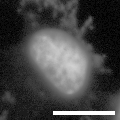
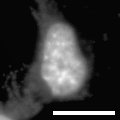
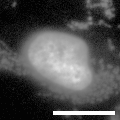
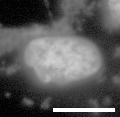
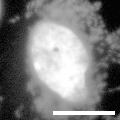
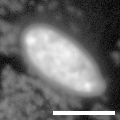

In [4]:
# compartment for bounding boxes
compartment = "Cytoplasm"

# metadata columns to include in output data frame
metadata_columns = [
    "Image_Metadata_Plate",
    "Image_Metadata_Well",
    "Image_Metadata_Site",
    "Metadata_Nuclei_Location_Center_X",
    "Metadata_Nuclei_Location_Center_Y",
    "Image_FileName_DAPI",
    "Image_PathName_DAPI",
    f"{compartment}_AreaShape_BoundingBoxMaximum_X",
    f"{compartment}_AreaShape_BoundingBoxMaximum_Y",
    f"{compartment}_AreaShape_BoundingBoxMinimum_X",
    f"{compartment}_AreaShape_BoundingBoxMinimum_Y",
]

# find irregular shaped nuclei
feature_thresholds = {
    # outlier threshold for only cytoplasm texture in nuclei channel
    "Cytoplasm_Texture_InfoMeas1_DAPI_3_02_256": 1,
}

irregular_nuclei_outliers = find_outliers(
    df=plate_df,
    metadata_columns=metadata_columns,
    feature_thresholds=feature_thresholds,
)

irregular_nuclei_outliers_cdf = CytoDataFrame(
    data=irregular_nuclei_outliers,
    display_options={
        "center_dot": False,
        "brightness": 35,
        "pixel_per_um": 3.1065,
        "scale_bar": {
            "length_um": 20,
            "location": "lower right",
            "color": (255, 255, 255),
            "thickness_px": 4,
            "margin_px": 5,
        },
        "offset_bounding_box": {
            "x_min": -60,
            "y_min": -60,
            "x_max": 60,
            "y_max": 60,
        },
    },
)[
    [
        "Image_FileName_DAPI",
        "Cytoplasm_Texture_InfoMeas1_DAPI_3_02_256",
        "Image_Metadata_Well",
        "Image_Metadata_Site",
        "Image_Metadata_Plate",
    ]
]

print(irregular_nuclei_outliers_cdf.shape)
irregular_nuclei_outliers_cdf.sort_values(
    by="Cytoplasm_Texture_InfoMeas1_DAPI_3_02_256", ascending=True
).head(6).T

Number of outliers: 2269 (12.58%)
Outliers Range:
Cytoplasm_Granularity_2_DAPI Min: 1.9138818048921382
Cytoplasm_Granularity_2_DAPI Max: 27.639655282904474
(2269, 5)


,Image_FileName_DAPI,Cytoplasm_Granularity_2_DAPI,Image_Metadata_Well,Image_Metadata_Site,Image_Metadata_Plate
17509,,2.267442,D8,15,Plate_3
13955,,3.949623,B7,11,Plate_3
14940,,2.581579,E8,21,Plate_3
6838,,3.668143,F8,23,Plate_3
15681,,2.790964,E8,17,Plate_3
8720,,4.903447,E8,17,Plate_3

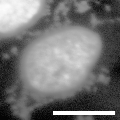
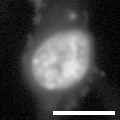
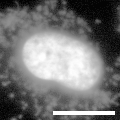
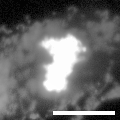
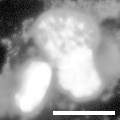
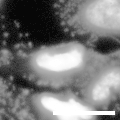

In [5]:
# find irregular shaped nuclei
feature_thresholds = {
    # outlier threshold for only cytoplasm texture in nuclei channel
    "Cytoplasm_Granularity_2_DAPI": 1,
}

extra_nuclei_outliers = find_outliers(
    df=plate_df,
    metadata_columns=metadata_columns,
    feature_thresholds=feature_thresholds,
)

extra_nuclei_outliers_cdf = CytoDataFrame(
    data=extra_nuclei_outliers,
    display_options={
        "center_dot": False,
        "brightness": 35,
        "pixel_per_um": 3.1065,
        "scale_bar": {
            "length_um": 20,
            "location": "lower right",
            "color": (255, 255, 255),
            "thickness_px": 4,
            "margin_px": 5,
        },
        "offset_bounding_box": {
            "x_min": -60,
            "y_min": -60,
            "x_max": 60,
            "y_max": 60,
        },
    },
)[
    [
        "Image_FileName_DAPI",
        "Cytoplasm_Granularity_2_DAPI",
        "Image_Metadata_Well",
        "Image_Metadata_Site",
        "Image_Metadata_Plate",
    ]
]

print(extra_nuclei_outliers_cdf.shape)
# Filter for wells in columns 5-8
extra_nuclei_outliers_cdf[
    extra_nuclei_outliers_cdf["Image_Metadata_Well"]
    .str.extract(r"(\d+)")
    .astype(int)[0]
    .between(5, 8)
].sort_values(by="Cytoplasm_Granularity_2_DAPI", ascending=False).sample(
    n=6, random_state=0
)

In [6]:
# Set QC_status column based on outlier dataframes
plate_df["QC_status"] = "Passed QC"
failed_indices = irregular_nuclei_outliers.index.union(extra_nuclei_outliers.index)
plate_df.loc[failed_indices, "QC_status"] = "Single-cell failed QC"

# Count failed QC cells per well
failed_qc_wells = plate_df.loc[
    plate_df["QC_status"] == "Single-cell failed QC", "Image_Metadata_Well"
]

failed_qc_counts = failed_qc_wells.value_counts().reset_index()
failed_qc_counts.columns = ["Image_Metadata_Well", "Failed_QC_Count"]

# Get total cell count per well
total_cells_per_well = plate_df["Image_Metadata_Well"].value_counts().reset_index()
total_cells_per_well.columns = ["Image_Metadata_Well", "Total_Cell_Count"]

# Merge total cells with failed counts — this keeps all wells
plot_df = total_cells_per_well.merge(
    failed_qc_counts, on="Image_Metadata_Well", how="left"
)
plot_df["Failed_QC_Count"] = plot_df["Failed_QC_Count"].fillna(0)

# Calculate percentage of failed QC cells per well
plot_df["Failed_QC_Proportion"] = (
    plot_df["Failed_QC_Count"] / plot_df["Total_Cell_Count"] * 100
)

# Extract row letter and column number for sorting
plot_df["Row"] = plot_df["Image_Metadata_Well"].str.extract(r"([A-Z])")
plot_df["Column"] = plot_df["Image_Metadata_Well"].str.extract(r"(\d+)").astype(int)

# Sort by column, then row
plot_df = plot_df.sort_values(["Column", "Row"])

# Update well order factor for x-axis to match new order
plot_df["Image_Metadata_Well"] = pd.Categorical(
    plot_df["Image_Metadata_Well"],
    categories=plot_df["Image_Metadata_Well"],
    ordered=True,
)

In [ ]:
# Assign genotype (blinded) based on column number directly
plot_df["Metadata_genotype"] = plot_df["Column"].apply(
    lambda col: (
        "cell_line_1"  # WT
        if 1 <= col <= 4  # noqa: PLR2004
        else (
            "cell_line_2"  # HET
            if 5 <= col <= 8  # noqa: PLR2004
            else "cell_line_3"
            if 9 <= col <= 12  # noqa: PLR2004
            else "Unknown"  # Null
        )
    )
)

print(plot_df.shape)
plot_df.head()

(72, 7)


,Image_Metadata_Well,Total_Cell_Count,Failed_QC_Count,Failed_QC_Proportion,Row,Column,Metadata_genotype
65,B1,43,0.0,0.000000,B,1,cell_line_1
58,C1,64,1.0,1.562500,C,1,cell_line_1
68,D1,34,0.0,0.000000,D,1,cell_line_1
61,E1,51,1.0,1.960784,E,1,cell_line_1
67,F1,39,0.0,0.000000,F,1,cell_line_1


/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-vNopUmqk-py3.11/lib/python3.11/site-packages/plotnine/ggplot.py:606: PlotnineWarning: Saving 8 x 8 in image.
/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-vNopUmqk-py3.11/lib/python3.11/site-packages/plotnine/ggplot.py:607: PlotnineWarning: Filename: figures/barplot_partial_contamination.png


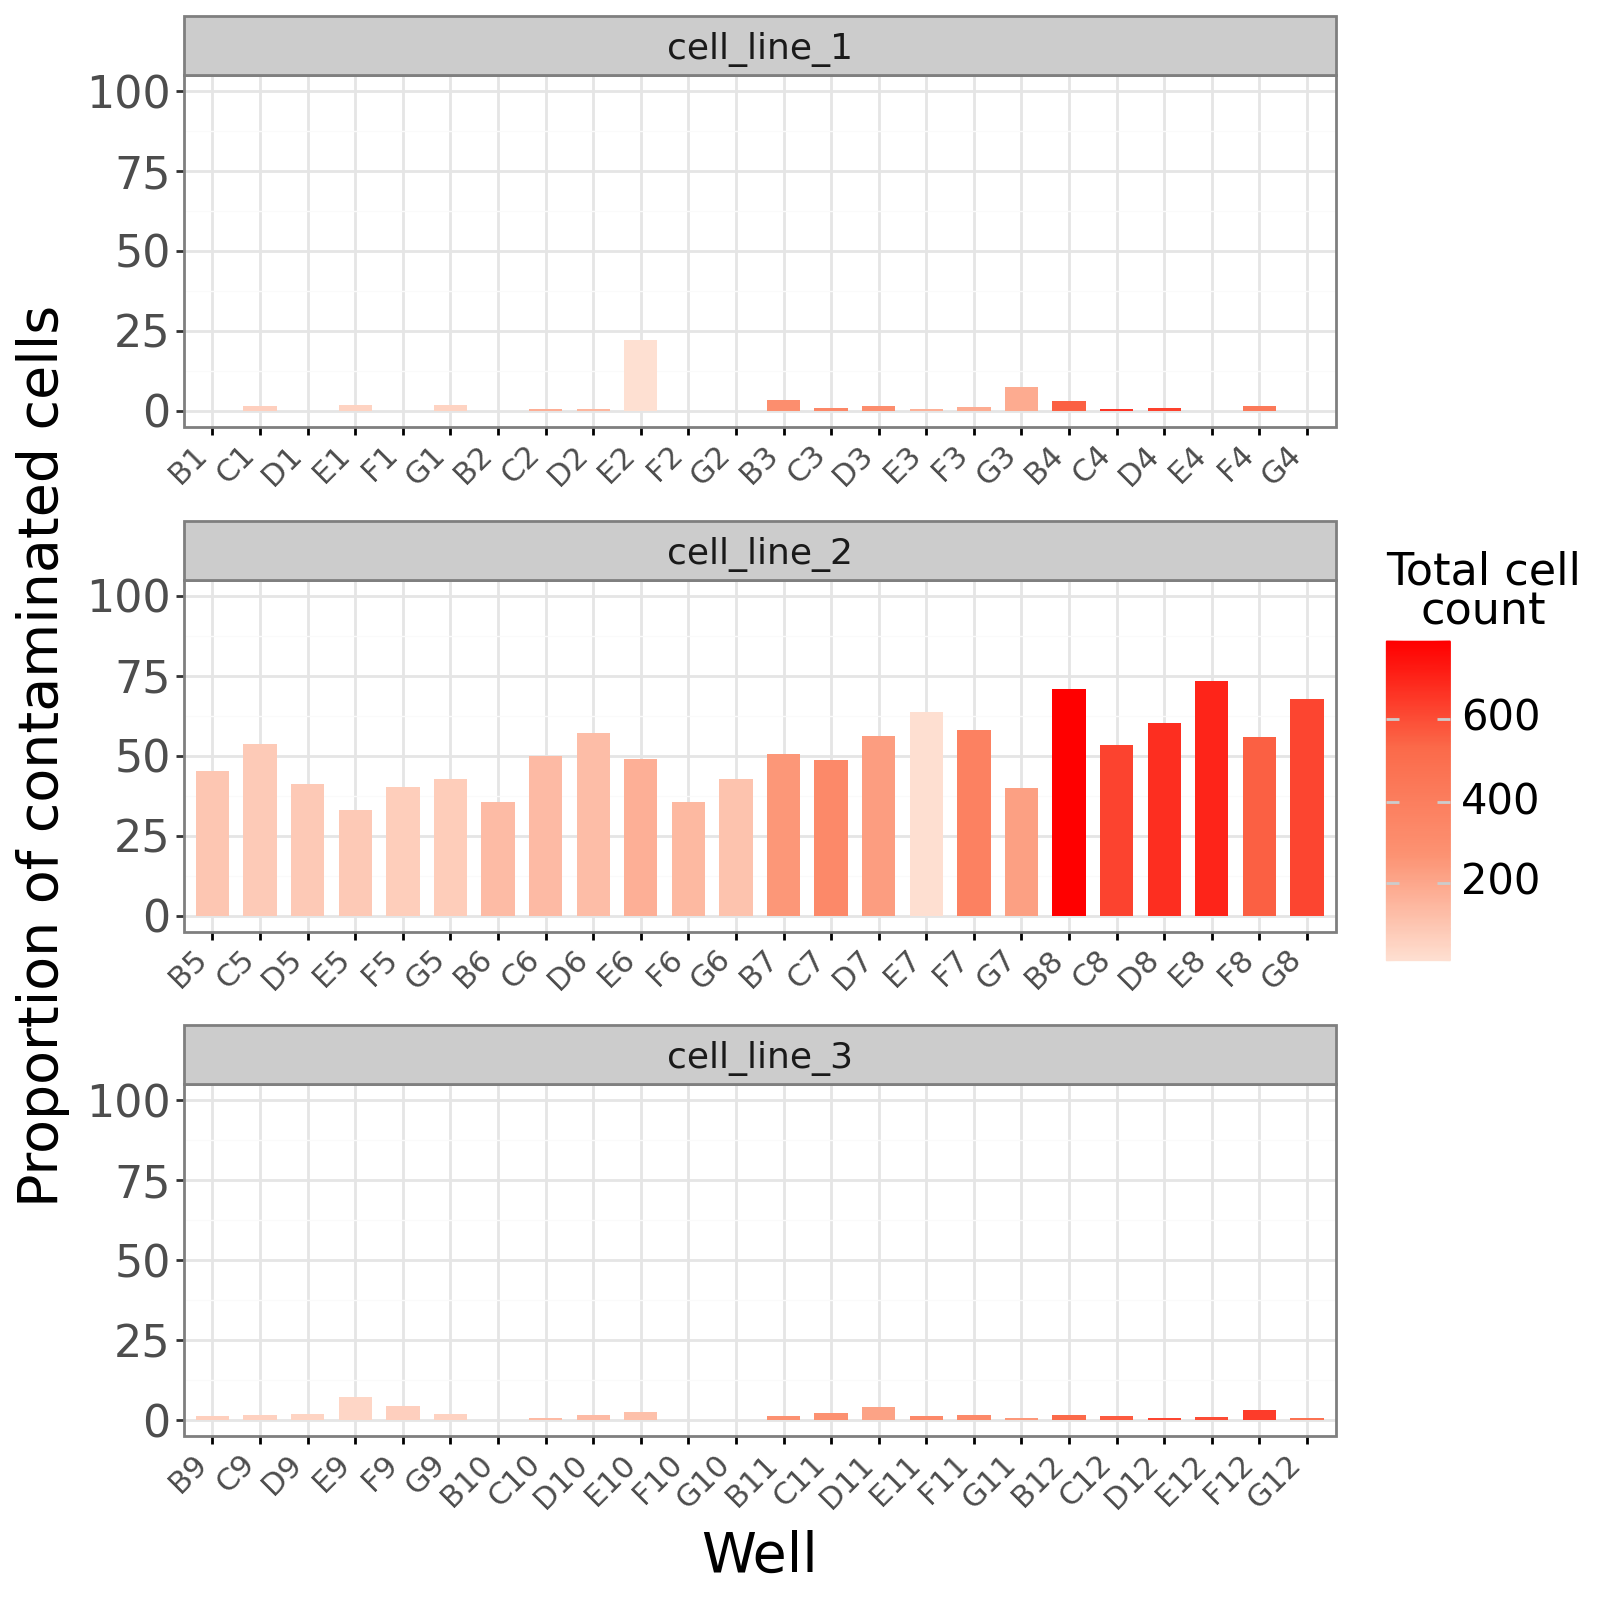

In [8]:
# Set facet order: cell_line_1, cell_line_2, cell_line_3
genotype_order = ["cell_line_1", "cell_line_2", "cell_line_3"]
plot_df["Metadata_genotype"] = pd.Categorical(
    plot_df["Metadata_genotype"], categories=genotype_order, ordered=True
)

# Set the figure size
height = 8
width = 8
set_option("figure_size", (width, height))

# Create bar plot of proportion failed per well
p = (
    ggplot(
        plot_df,
        aes(x="Image_Metadata_Well", y="Failed_QC_Proportion", fill="Total_Cell_Count"),
    )
    + geom_bar(stat="identity", width=0.7)
    + scale_fill_gradientn(colors=["#FEE0D2", "#FC9272", "#FB6A4A", "#FF0000"])
    + labs(x="Well", y="Proportion of contaminated cells", fill="Total cell\ncount")
    + theme_bw()
    + facet_wrap("Metadata_genotype", scales="free_x", ncol=1)
    + ylim(0, 100)
    + theme(
        axis_text_x=element_text(angle=45, hjust=1, size=11),
        axis_text_y=element_text(size=16),
        axis_title=element_text(size=20),
        legend_title=element_text(size=16),
        legend_text=element_text(size=15),
        strip_text=element_text(size=13),  # Increase facet font size
    )
)

# Save the plot
p.save(
    figure_dir / "barplot_partial_contamination.png",
    dpi=600,
    width=width,
    height=height,
)

p.show()